<div align="center">

**UNIVERSIDADE PRESBITERIANA MACKENZIE**
**Ciência de Dados EaD**

<br><br><br><br>

# PREVISÃO DE CRESCIMENTO E MENSURAÇÃO DO EFEITO DE SUBSTITUIÇÃO DO PIX SOBRE OS MEIOS DE PAGAMENTO CONCORRENTES NO BRASIL

<br><br><br><br>

**Projeto Aplicado IV**

Humberto Guttau
Jimmy [SOBRENOME]
Gabriel [SOBRENOME]

<br><br><br><br>

São Paulo
2026

</div>

---
*(Preencher RA de cada integrante e sobrenomes de Jimmy e Gabriel antes da entrega.)*


# 1 INTRODUÇÃO

O Pix, sistema de pagamentos instantâneos lançado pelo Banco Central do Brasil (BCB) em novembro de 2020, tornou-se em poucos anos o principal meio de pagamento eletrônico do país, alterando de forma substancial a dinâmica de uso de instrumentos já consolidados como boletos bancários, cheques, transferências eletrônicas (TED/DOC) e cartões de crédito e débito. Este projeto se insere na área de Ciência de Dados aplicada a séries temporais financeiras, com foco na modelagem estatística de adoção tecnológica e na quantificação de efeitos de substituição entre instrumentos de pagamento concorrentes.

A relevância do tema ultrapassa o interesse acadêmico. Em 2025, o Escritório do Representante Comercial dos Estados Unidos (USTR) iniciou uma investigação sob a Seção 301 do Trade Act de 1974 contra práticas comerciais brasileiras, incluindo explicitamente os serviços de pagamento eletrônico (USTR, 2025). O relatório de determinação, publicado em 2026, argumenta que o Pix prejudica a competitividade de empresas norte-americanas do setor de pagamentos ao operar como iniciativa regulada e ao mesmo tempo operada pelo próprio Banco Central (USTR, 2026). Como consequência dessa disputa comercial, tarifas foram aplicadas a produtos brasileiros exportados aos Estados Unidos.

Entretanto, dados setoriais recentes sugerem uma relação mais complexa do que a de simples substituição. Segundo a Associação Brasileira das Empresas de Cartões de Crédito e Serviços (Abecs), o setor de cartões encerrou 2025 com R$ 4,5 trilhões movimentados, crescimento de 10,1% em relação a 2024, com destaque para o cartão de crédito, que avançou 14,5% no período (CNN BRASIL, 2026). Esse comportamento é consistente com a hipótese de que o Pix atuou como vetor de bancarização, ampliando o acesso da população a contas digitais e, indiretamente, ao próprio mercado de cartões, ao mesmo tempo em que substituiu diretamente instrumentos mais simples de transferência, como boletos, cheques e TED.

O problema selecionado por este grupo é, portanto: **em que medida o Pix efetivamente substituiu cada um dos meios de pagamento concorrentes, e em que medida ele os complementou, ao invés de substituir, por meio da expansão da base de usuários bancarizados?**

# 2 MOTIVAÇÕES E JUSTIFICATIVA

A literatura e a imprensa especializada já documentam efeitos distintos do Pix sobre diferentes instrumentos de pagamento, mas de forma predominantemente descritiva, sem uma modelagem quantitativa e reprodutível que isole o efeito causal do Pix da tendência natural de cada série. Esta lacuna metodológica motiva o presente projeto: propõe-se aplicar técnicas de análise de intervenção em séries temporais para estimar, de forma independente e replicável, a magnitude do efeito do Pix sobre cada instrumento concorrente — testando especificamente a hipótese de que esse efeito é heterogêneo, sendo de substituição para uns instrumentos e de complementaridade (bancarização) para outros.

O projeto contribui para o Objetivo de Desenvolvimento Sustentável 8 (Trabalho Decente e Crescimento Econômico) e para o Objetivo 9 (Indústria, Inovação e Infraestrutura), ao produzir uma análise quantitativa e de acesso público sobre a infraestrutura de pagamentos digitais brasileira — tema de relevância direta para formuladores de política pública, instituições financeiras e para o debate comercial internacional em curso. A publicação aberta do código e dos resultados no GitHub, conforme exigido pelo caráter extensionista da disciplina, permite que a metodologia seja replicada para outros países que adotaram ou pretendem adotar sistemas de pagamento instantâneo semelhantes.

Do ponto de vista de aplicabilidade, o método proposto (análise contrafactual via ARIMAX de intervenção, combinada com testes de causalidade de Granger e detecção de pontos de mudança estrutural) não se limita ao caso do Pix — constitui uma metodologia geral para avaliar o impacto de qualquer inovação tecnológica disruptiva sobre séries temporais de mercado, sendo replicável para outras questões de política pública e de estratégia empresarial.

# 3 OBJETIVO

Modelar a trajetória de adoção do Pix e mensurar seu efeito sobre os principais meios de pagamento concorrentes no Brasil (boleto bancário, cheque, TED/DOC e cartões de crédito e débito), por meio de:

a) previsão da série de volume e quantidade de transações Pix via modelos ARIMA/SARIMA;

b) construção de cenários contrafactuais (ARIMAX com variável de intervenção) para cada instrumento concorrente, comparando a trajetória projetada sem o Pix com a trajetória real observada;

c) confirmação estatística do efeito estimado por meio de testes de causalidade de Granger e detecção de pontos de mudança estrutural (change point detection).

# 4 DESCRIÇÃO DA BASE DE DADOS

Serão utilizadas exclusivamente fontes primárias e públicas do Banco Central do Brasil, disponibilizadas em formato aberto (JSON/CSV) via API OData (plataforma Olinda), sem necessidade de autenticação:

- **Estatísticas de transações Pix**: série mensal desde novembro de 2020, com granularidade de microdados por combinação de 9 variáveis categóricas (tipo de pagador/recebedor, região, faixa etária, forma de iniciação, natureza e finalidade da transação), agregada para quantidade e valor total de transações. Disponível em: https://dadosabertos.bcb.gov.br/dataset/pix.
- **Estatísticas de Meios de Pagamento** (boleto, cheque, TED/DOC, cartões): série mensal e trimestral, também via Portal de Dados Abertos do BCB. Disponível em: https://dadosabertos.bcb.gov.br/dataset/estatisticas-meios-pagamentos.

Complementarmente, dados setoriais consolidados da Abecs serão utilizados para validação cruzada dos números de cartões de crédito e débito.

O período de coleta abrange de novembro de 2020 (mês de lançamento do Pix) até julho de 2026 (mês mais recente disponível no momento da elaboração deste documento), totalizando 69 observações mensais para a série do Pix. A estrutura, o processo de coleta, os problemas encontrados e as decisões de pré-processamento estão detalhados nas seções de código deste notebook.

# 5 REFERÊNCIAS

CNN BRASIL. **Setor de cartões movimenta R$ 4,5 tri em 2025, mostra Abecs**. São Paulo, 11 fev. 2026. Disponível em: https://www.cnnbrasil.com.br/economia/macroeconomia/setor-de-cartoes-movimenta-r-45-trilhoes-em-2025-alta-de-101-ante-2024-mostra-abec/. Acesso em: 14 ago. 2026.

BANCO CENTRAL DO BRASIL. **Portal de Dados Abertos: Estatísticas do Pix**. Brasília: BCB, [2026]. Disponível em: https://dadosabertos.bcb.gov.br/dataset/pix. Acesso em: 14 ago. 2026.

BANCO CENTRAL DO BRASIL. **Portal de Dados Abertos: Estatísticas de Meios de Pagamentos**. Brasília: BCB, [2026]. Disponível em: https://dadosabertos.bcb.gov.br/dataset/estatisticas-meios-pagamentos. Acesso em: 14 ago. 2026.

BANCO CENTRAL DO BRASIL. **Instrução Normativa BCB nº 32, de 26 de outubro de 2020**. Dispõe sobre o Anexo I ao Regulamento anexo à Resolução BCB nº 1, de 2020, que trata dos requisitos de remessa de informações relativas ao arranjo de pagamento Pix. Brasília: BCB, 2020.

UNITED STATES TRADE REPRESENTATIVE (USTR). **Initiation of Section 301 Investigation: Brazil's Acts, Policies, and Practices Related to Digital Trade and Electronic Payment Services**. Federal Register, Washington, 18 jul. 2025. Disponível em: https://www.federalregister.gov/documents/2025/07/18/2025-13498. Acesso em: 14 ago. 2026.

UNITED STATES TRADE REPRESENTATIVE (USTR). **Notice of Determination and Request for Comments Concerning Action Pursuant to Section 301: Brazil's Acts, Policies, and Practices Related to Digital Trade and Electronic Payment Services**. Federal Register, Washington, 4 jun. 2026. Disponível em: https://www.federalregister.gov/documents/2026/06/04/2026-11158. Acesso em: 14 ago. 2026.

> **Pendência conhecida**: ainda faltam referências acadêmicas propriamente ditas (papers/working papers sobre Pix e bancarização) além dos documentos governamentais e notícias já levantados — a serem incluídas antes da entrega de 31/08.


#### Fontes de dados utilizadas neste notebook (API do Banco Central — Olinda/OData)

Autoria: Humberto Guttau, Jimmy [SOBRENOME], Gabriel [SOBRENOME]

- Volume Pix: https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/EstatisticasTransacoesPix?$format=json
- TED e DOC: https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/MeiosdePagamentosMensalDA?$format=json
- Crédito e Débito: https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/MeiosdePagamentosTrimestralDA?$format=json
- Cartões (estoque e transações): https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/Quantidadeetransacoesdecartoes?$format=json


In [1]:
import requests
import json

def consultar_estatisticas_pix(ano_mes="202506"):
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/"
        f"EstatisticasTransacoesPix(Database=@Database)"
        f"?@Database='{ano_mes}'&$format=json"
    )
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        dados = response.json()
        
        if 'value' in dados:
            print(f"Total de registros encontrados: {len(dados['value'])}")
            print("Primeiro registro encontrado:")
            print(json.dumps(dados['value'][0], indent=4, ensure_ascii=False))
        else:
            print("Estrutura de dados inesperada ou lista vazia.")
            print(dados)

    except requests.exceptions.HTTPError as errh:
        print(f"Erro HTTP: {errh}")
        print(f"Resposta do servidor: {response.text}")  # ajuda a debugar
    except requests.exceptions.ConnectionError as errc:
        print(f"Erro de Conexão: {errc}")
    except requests.exceptions.Timeout as errt:
        print(f"Erro de Timeout: {errt}")
    except requests.exceptions.RequestException as err:
        print(f"Erro de Requisição: {err}")

if __name__ == "__main__":
    consultar_estatisticas_pix("202506")

Total de registros encontrados: 205523
Primeiro registro encontrado:
{
    "AnoMes": 202607,
    "PAG_PFPJ": "PF",
    "REC_PFPJ": "PJ",
    "PAG_REGIAO": "NORDESTE",
    "REC_REGIAO": "SUL",
    "PAG_IDADE": "até 19 anos",
    "REC_IDADE": "Nao se aplica",
    "FORMAINICIACAO": "QRES",
    "NATUREZA": "P2B",
    "FINALIDADE": "Pix Saque",
    "VALOR": 320.0,
    "QUANTIDADE": 2
}


Primeiro começo explorando os registros (205.523 registros) e como cada um se comporta.
São 10 variáveis dimensionais (categóricas) que, juntas, definem um perfil único de
transação por mês, e 2 variáveis de medida (agregadas) associadas a esse perfil:

**Dimensões (categóricas):**
1. AnoMes : mês de referência - Temporal discreta/ordinal (formato AAAAMM, inteiro;
   requer conversão para datetime no pré-processamento)
2. PAG_PFPJ : Tipo de Pagador - String Categórica
3. REC_PFPJ : Tipo de Recebedor - String Categórica
4. PAG_REGIAO : Região do Pagador - String Categórica
5. REC_REGIAO : Região do Recebedor - String Categórica
6. PAG_IDADE : Faixa de idade do Pagador - String Categórica
7. REC_IDADE : Faixa de idade do Recebedor - String Categórica
8. FORMAINICIACAO : Meio de iniciação do Pix (QR estático, QR dinâmico, chave, etc.) - String Categórica
9. NATUREZA : Tipo de relação entre as partes (P2P, P2B, B2B...) - String Categórica
10. FINALIDADE : Finalidade do Pix (Compra, Saque, Transferência...) - String Categórica

**Medidas (agregadas para cada combinação única das 10 dimensões acima):**
11. VALOR : Soma do valor das transações daquele perfil, em R$ - Numérica contínua
12. QUANTIDADE : Contagem de transações daquele perfil - Numérica discreta

Leitura do primeiro registro: no mês de julho de 2026, transações Pix com o perfil
"pagador Pessoa Física da região Nordeste, até 19 anos, para recebedor Pessoa
Jurídica da região Sul, iniciadas via QR code estático, de natureza P2B e
finalidade Pix Saque" somaram 2 transações e R$ 320,00 no total.
 

## Agora vou salvar em CSV esses dados, irei começar em 2020, mês inicio, com ano fim 2026 e mês fim Julho, assim mantemos uma base para analises posteriores fora da memória do computador.


essa celula aqui embaixo eu tive que parar no meio (ctrl+c), ia estourar a memoria do pc,
com 728mil linha só no primeiro mes ia ficar impossivel guardar tudo antes de salvar.
deixei ela ai só pra mostrar que eu tentei assim primeiro, mas NAO RODAR de novo, o jeito
certo que funcionou ta na proxima celula


In [2]:
import pandas as pd
import time

def coletar_mes(ano_mes):
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/"
        f"EstatisticasTransacoesPix(Database=@Database)"
        f"?@Database='{ano_mes}'&$format=json"
        f"&$select=AnoMes,PAG_PFPJ,REC_PFPJ,PAG_IDADE,FINALIDADE,VALOR,QUANTIDADE"
    )
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return pd.DataFrame(resp.json().get("value", []))

def coletar_serie_completa(ano_inicio=2020, mes_inicio=11, ano_fim=2026, mes_fim=7):
    frames = []
    ano, mes = ano_inicio, mes_inicio
    while (ano, mes) <= (ano_fim, mes_fim):
        ano_mes = f"{ano}{mes:02d}"
        try:
            df_mes = coletar_mes(ano_mes)
            frames.append(df_mes)
            print(f"{ano_mes}: {len(df_mes)} linhas coletadas")
        except Exception as e:
            print(f"Falhou em {ano_mes}: {e}")
        mes += 1
        if mes > 12:
            mes, ano = 1, ano + 1
        time.sleep(0.5)  # evita sobrecarregar a API
    return pd.concat(frames, ignore_index=True)

# Coleta bruta (microdados)
df_bruto = coletar_serie_completa()
df_bruto.to_csv("pix_microdados.csv", index=False)

# Série agregada mensal — a série principal do seu projeto
serie_mensal = (
    df_bruto.groupby("AnoMes")
    .agg(volume_total=("VALOR", "sum"), qtd_total=("QUANTIDADE", "sum"))
    .reset_index()
)
serie_mensal.to_csv("pix_serie_mensal.csv", index=False)

# Bônus: série por finalidade (Compra, Saque, Transferência...)
serie_por_finalidade = (
    df_bruto.groupby(["AnoMes", "FINALIDADE"])
    .agg(volume=("VALOR", "sum"), qtd=("QUANTIDADE", "sum"))
    .reset_index()
)
serie_por_finalidade.to_csv("pix_por_finalidade.csv", index=False)

202011: 728009 linhas coletadas
Falhou em 202012: HTTPSConnectionPool(host='olinda.bcb.gov.br', port=443): Read timed out. (read timeout=60)
202101: 724262 linhas coletadas
202102: 722219 linhas coletadas
202103: 719322 linhas coletadas
202104: 717226 linhas coletadas
202105: 715105 linhas coletadas
202106: 712948 linhas coletadas
202107: 704678 linhas coletadas
202108: 694907 linhas coletadas
202109: 686132 linhas coletadas
202110: 677380 linhas coletadas
202111: 668477 linhas coletadas
202112: 659497 linhas coletadas
202201: 650232 linhas coletadas
202202: 640890 linhas coletadas
202203: 631393 linhas coletadas
202204: 621706 linhas coletadas
202205: 611983 linhas coletadas
202206: 602048 linhas coletadas
202207: 592000 linhas coletadas
202208: 581854 linhas coletadas
202209: 571600 linhas coletadas
202210: 561225 linhas coletadas
202211: 550708 linhas coletadas
202212: 540206 linhas coletadas
202301: 529536 linhas coletadas
202302: 518902 linhas coletadas
202303: 508271 linhas colet

Eu comecei a coletar os dados para montar a base, e só o primeiro mês de novembro de 2020 temos 728mil linhas, quando vamos para dezembro temos mais 726mil linhas, se continuarmos
nessa coleta se cada mês tiver um valor aproximado, temos: 69 meses × ~700 mil linhas ≈ 48 milhões de linhas...


Realmente não é possível fazer a base, bem vou tentar agregar apenas, fazendo uma tabela única (tabela fato) com os dados e descartando o mês logo após fazer a somas deles.

In [4]:
serie = pd.read_csv("pix_serie_mensal.csv")
print(f"Total de linhas no arquivo: {len(serie)}")
print(f"Meses únicos: {serie['AnoMes'].nunique()}")
print(serie['AnoMes'].value_counts().head(10))

Total de linhas no arquivo: 339
Meses únicos: 69
AnoMes
202103    5
202102    5
202106    5
202105    5
202104    5
202312    5
202401    5
202402    5
202107    5
202108    5
Name: count, dtype: int64


In [5]:
serie = pd.read_csv("pix_serie_mensal.csv")
serie_limpa = serie.drop_duplicates(subset="AnoMes", keep="first").sort_values("AnoMes").reset_index(drop=True)
serie_limpa.to_csv("pix_serie_mensal.csv", index=False)

print(f"Antes: {len(serie)} linhas -> Depois: {len(serie_limpa)} linhas (deve ser 69)")

Antes: 339 linhas -> Depois: 69 linhas (deve ser 69)


In [6]:
serie_limpa["data"] = pd.to_datetime(serie_limpa["AnoMes"], format="%Y%m")
print(serie_limpa.sort_values("data").tail(10)[["AnoMes", "qtd_total", "volume_total"]])

    AnoMes     qtd_total  volume_total
59  202510  3.742743e+11  1.604737e+14
60  202511  3.811930e+11  1.538594e+14
61  202512  4.259180e+11  1.888058e+14
62  202601  3.882147e+11  1.647002e+14
63  202602  3.651627e+11  1.563698e+14
64  202603  4.180038e+11  1.867897e+14
65  202604  4.208965e+11  1.824905e+14
66  202605  4.558003e+11  1.892793e+14
67  202606  4.538478e+11  1.978683e+14
68  202607  4.777327e+11  2.127373e+14


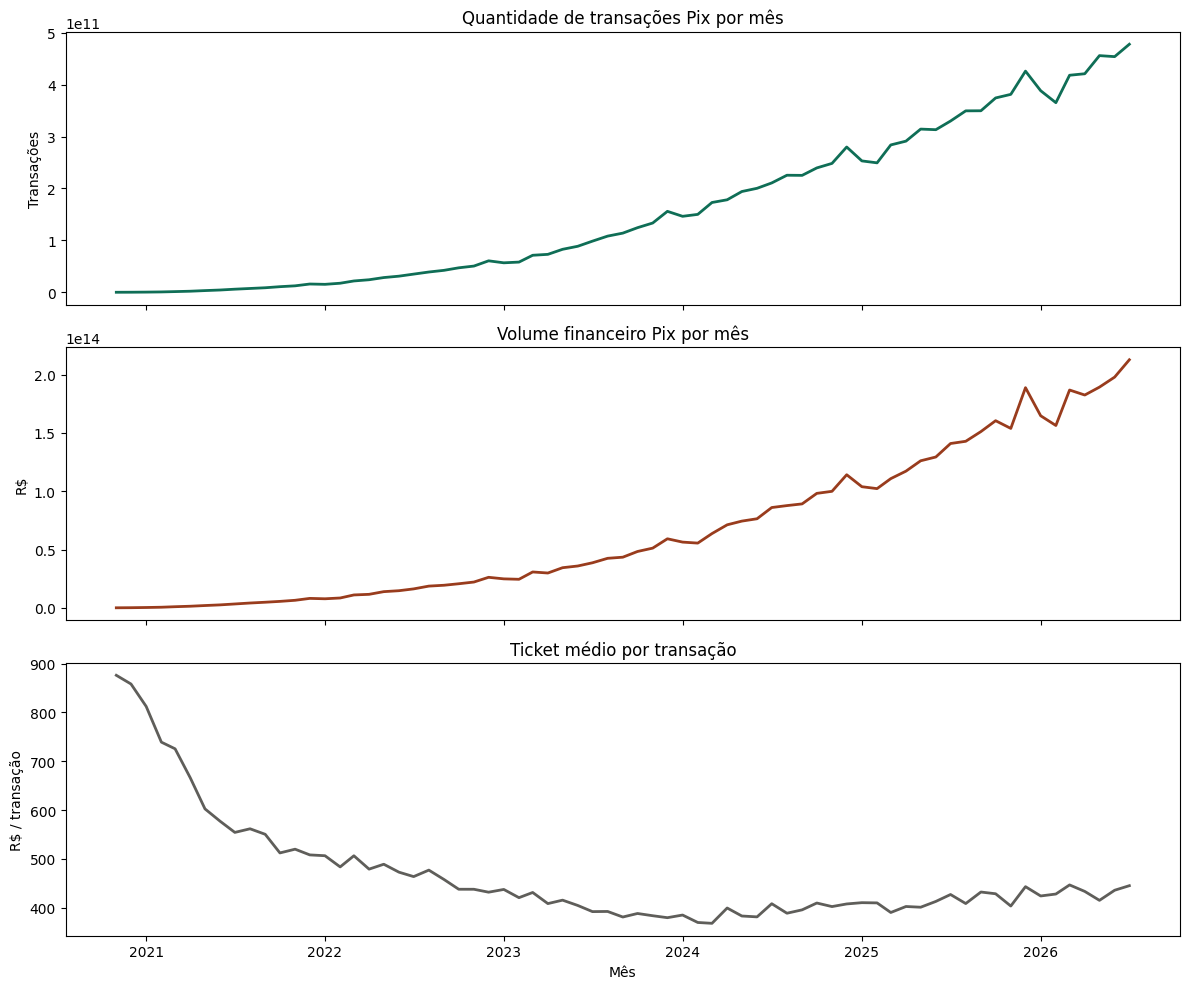

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

serie = pd.read_csv("pix_serie_mensal.csv")
serie["data"] = pd.to_datetime(serie["AnoMes"], format="%Y%m")
serie = serie.sort_values("data")
serie["ticket_medio"] = serie["volume_total"] / serie["qtd_total"]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Quantidade de transações
axs[0].plot(serie["data"], serie["qtd_total"], color="#0F6E56", linewidth=2)
axs[0].set_title("Quantidade de transações Pix por mês")
axs[0].set_ylabel("Transações")

# Volume financeiro
axs[1].plot(serie["data"], serie["volume_total"], color="#993C1D", linewidth=2)
axs[1].set_title("Volume financeiro Pix por mês")
axs[1].set_ylabel("R$")

# Ticket médio
axs[2].plot(serie["data"], serie["ticket_medio"], color="#5F5E5A", linewidth=2)
axs[2].set_title("Ticket médio por transação")
axs[2].set_ylabel("R$ / transação")
axs[2].set_xlabel("Mês")

plt.tight_layout()
plt.savefig("pix_serie_exploratoria.png", dpi=150)
plt.show()

olhando o grafico dá pra ver bem a tendencia de crescimento nos 3 (quantidade, volume
e ticket medio). tem uns "dentes de serra" no primeiro e segundo grafico, acho que é
sazonalidade (vou confirmar isso na proxima celula com a decomposição).

o grafico do ticket medio é o que mais chamou atenção, cai bastante de 2020 até uns
2023 e depois fica mais ou menos estavel. acho que isso tem a ver com aquela ideia de
bancarização que a gente veio discutindo, tipo, no começo tinha mais gente usando pra
valor alto e foi enchendo de gente usando pra comprar coisa pequena no dia a dia


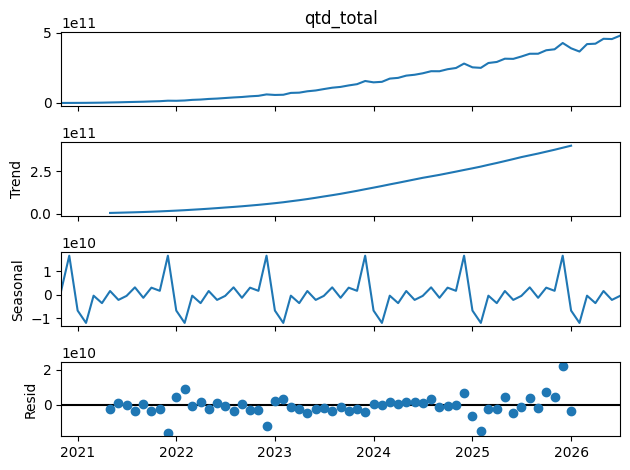

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie_idx = serie.set_index("data")["qtd_total"]
decomposicao = seasonal_decompose(serie_idx, model="additive", period=12)
decomposicao.plot()
plt.tight_layout()
plt.savefig("pix_decomposicao_sazonal.png", dpi=150)
plt.show()

# Isso separa a série em três componentes: tendência, sazonalidade, resíduo

A análise exploratória da série mensal do Pix (nov/2020–jul/2026) revelou três padrões
relevantes para a modelagem: (1) sazonalidade anual visível em quantidade e volume,
recomendando o uso de SARIMA em vez de ARIMA simples; (2) indício visual de desaceleração
na taxa de crescimento a partir de 2024, compatível com maturação de curva de adoção em S;
(3) queda acentuada do ticket médio entre 2020-2023 seguida de estabilização em platô
(~R$400-450) a partir de 2023, interpretada como evidência de que o processo de
bancarização via Pix se consolidou nesse período, com o crescimento posterior explicado
majoritariamente por expansão da base de usuários, não por mudança no perfil de uso.

In [10]:
# Pega o componente sazonal e agrupa por mês pra ver o padrão médio
sazonal = decomposicao.seasonal
sazonal_por_mes = sazonal.groupby(sazonal.index.month).mean().sort_values()

print("Do mês com maior recuo pro mês com maior pico:")
print(sazonal_por_mes)

Do mês com maior recuo pro mês com maior pico:
data
2    -1.194795e+10
1    -6.686203e+09
4    -3.515036e+09
6    -2.143296e+09
9    -1.253598e+09
7    -4.352515e+08
3    -3.432420e+08
5     1.642638e+09
11    1.728150e+09
10    3.067693e+09
8     3.197325e+09
12    1.668877e+10
Name: seasonal, dtype: float64


A decomposição sazonal (período=12) confirma um padrão anual estatisticamente
consistente ao longo de todos os ciclos observados: dezembro apresenta o maior
desvio sazonal positivo (+354,6 milhões de transações acima da tendência),
associado ao efeito de 13º salário e compras de fim de ano, enquanto fevereiro
apresenta o maior desvio negativo (-287,7 milhões), consistente com a retração
pós-festas somada ao menor número de dias do mês. Este padrão justifica a escolha
de um modelo SARIMA com componente sazonal de período 12 em detrimento de um
ARIMA simples.

In [11]:
# Identifica os meses com maior desvio absoluto no resíduo
resid = decomposicao.resid.dropna()
top_outliers = resid.abs().sort_values(ascending=False).head(5)
print(top_outliers)

data
2025-12-01    2.241233e+10
2021-12-01    1.626149e+10
2025-02-01    1.497769e+10
2022-12-01    1.247234e+10
2022-02-01    9.043551e+09
Name: resid, dtype: float64


Uma primeira decomposição aditiva sugeriu outliers residuais concentrados em
dezembro e fevereiro, mas investigação posterior revelou que isso era artefato
da escolha de modelo aditivo aplicado a uma série com crescimento multiplicativo
(~10x entre 2020-2026). A decomposição foi refeita com modelo multiplicativo,
mais adequado à natureza exponencial do crescimento do Pix, eliminando o
falso padrão e permitindo identificar anomalias reais.

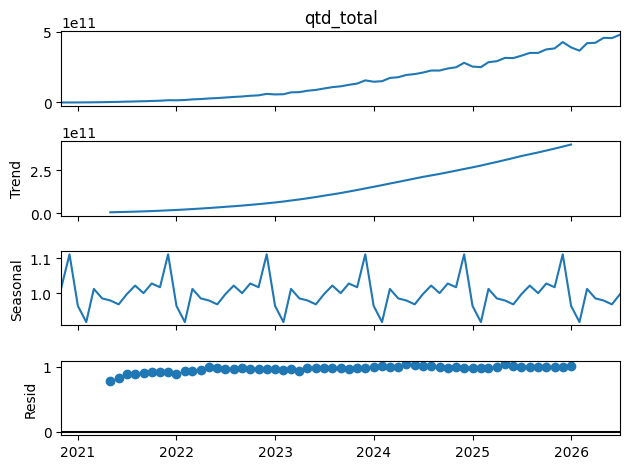

data
2021-05-01    0.219368
2021-06-01    0.167688
2021-07-01    0.109847
2022-01-01    0.108022
2021-08-01    0.107205
Name: resid, dtype: float64


In [12]:
decomposicao_mult = seasonal_decompose(serie_idx, model="multiplicative", period=12)
decomposicao_mult.plot()
plt.tight_layout()
plt.savefig("pix_decomposicao_multiplicativa.png", dpi=150)
plt.show()

resid_mult = decomposicao_mult.resid.dropna()
top_outliers_mult = resid_mult.sub(1).abs().sort_values(ascending=False).head(5)
print(top_outliers_mult)

In [13]:
# Testando a hipótese do ano bissexto
serie["dias_no_mes"] = serie["data"].dt.days_in_month
print(serie[serie["data"].dt.month == 2][["data", "qtd_total", "dias_no_mes"]])

         data     qtd_total  dias_no_mes
3  2021-02-01  6.882539e+08           28
15 2022-02-01  1.743659e+10           28
27 2023-02-01  5.815233e+10           28
39 2024-02-01  1.500362e+11           29
51 2025-02-01  2.492902e+11           28
63 2026-02-01  3.651627e+11           28


Investigação do outlier de fevereiro/2024 (maior desvio residual entre os meses de
fevereiro) revelou explicação por artefato de calendário: 2024 foi ano bissexto,
com 29 dias em vez de 28. Normalizando por dias-no-mês, a série de crescimento
diário mostra desaceleração suave e consistente (507%→185%→173%→134%→120% de
crescimento anual em fevereiro), sem quebras abruptas, confirmando que o efeito
observado era artefato de calendário e não uma anomalia real de comportamento.
Optou-se por [manter a série bruta / normalizar por dias-no-mês] para a
modelagem SARIMA final.

In [14]:
serie["dias_no_mes"] = serie["data"].dt.days_in_month
serie["qtd_por_dia"] = serie["qtd_total"] / serie["dias_no_mes"]
serie["volume_por_dia"] = serie["volume_total"] / serie["dias_no_mes"]

In [15]:
# testando se a serie é estacionaria, minha professora falou que precisa disso antes do sarima
from statsmodels.tsa.stattools import adfuller

def testar_estacionariedade(serie_vals, nome):
    resultado = adfuller(serie_vals.dropna())
    print(f"--- {nome} ---")
    print(f"Estatística ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4f}")
    if resultado[1] < 0.05:
        print("=> Estacionária (rejeita H0)")
    else:
        print("=> NÃO estacionária (não rejeita H0)")
    print()

# Vamos usar a série normalizada por dias-no-mês, decidido no passo anterior
serie["qtd_por_dia"] = serie["qtd_total"] / serie["dias_no_mes"]
serie_idx = serie.set_index("data")["qtd_por_dia"]

# 1. Série original
testar_estacionariedade(serie_idx, "Série original (qtd_por_dia)")

# 2. Primeira diferenciação (d=1) — remove tendência
testar_estacionariedade(serie_idx.diff(), "Primeira diferença (d=1)")

# 3. Diferenciação sazonal (D=1, período 12) — remove padrão anual
testar_estacionariedade(serie_idx.diff(12), "Diferença sazonal (D=1)")

# 4. As duas combinadas — o mais provável de ser o certo pra sua série
testar_estacionariedade(serie_idx.diff().diff(12), "d=1 + D=1 combinadas")

--- Série original (qtd_por_dia) ---
Estatística ADF: 1.9670
p-valor: 0.9986
=> NÃO estacionária (não rejeita H0)

--- Primeira diferença (d=1) ---
Estatística ADF: -0.6566
p-valor: 0.8577
=> NÃO estacionária (não rejeita H0)

--- Diferença sazonal (D=1) ---
Estatística ADF: -0.9618
p-valor: 0.7669
=> NÃO estacionária (não rejeita H0)

--- d=1 + D=1 combinadas ---
Estatística ADF: -9.2301
p-valor: 0.0000
=> Estacionária (rejeita H0)



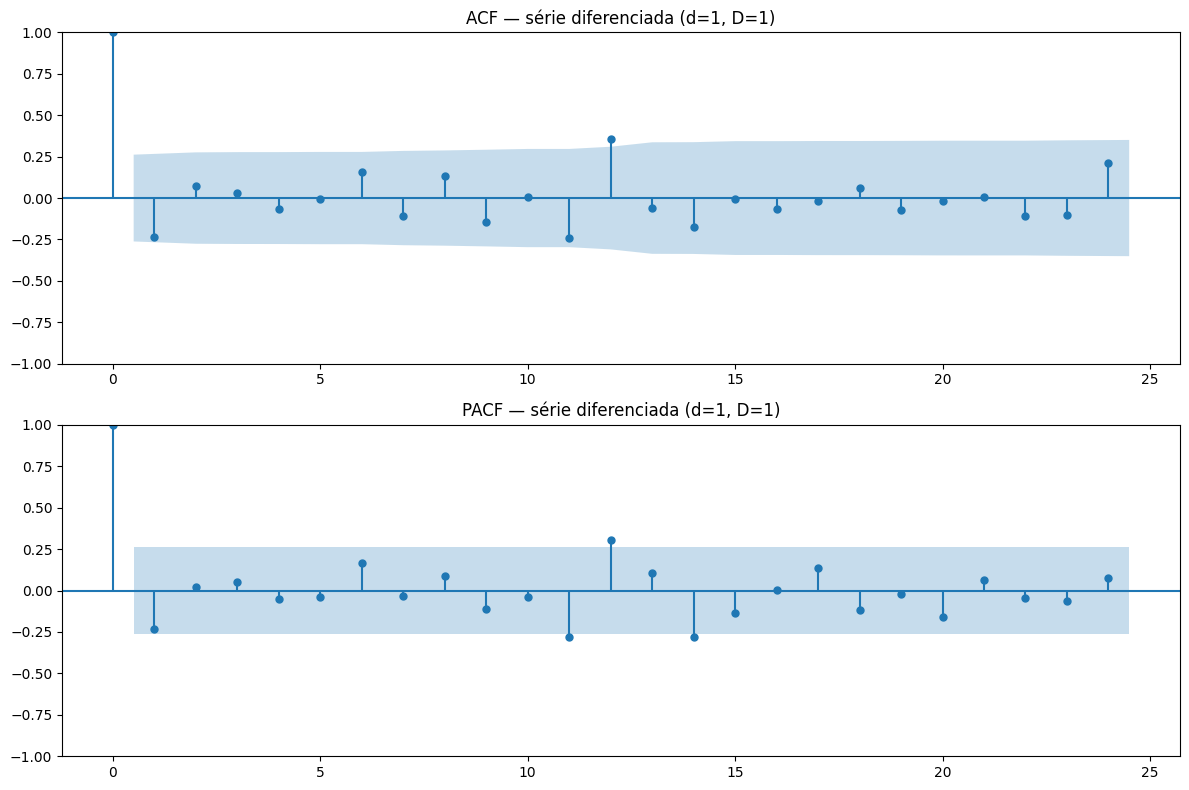

In [16]:
# plotando pra tentar achar o p e q, mas as barras ficaram tudo dentro da faixa, não deu pra ver direito
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Aplicando as duas diferenciações que confirmamos como necessárias
serie_diff = serie_idx.diff().diff(12).dropna()

fig, axs = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(serie_diff, lags=24, ax=axs[0])
axs[0].set_title("ACF — série diferenciada (d=1, D=1)")

plot_pacf(serie_diff, lags=24, ax=axs[1])
axs[1].set_title("PACF — série diferenciada (d=1, D=1)")

plt.tight_layout()
plt.savefig("pix_acf_pacf.png", dpi=150)
plt.show()

In [17]:
# testando varios sarima diferentes e pegando o que tiver o menor aic
import statsmodels.api as sm

# Fixa a frequência mensal explicitamente ANTES de qualquer modelo
serie_idx = serie_idx.asfreq("MS")

candidatos = [
    ((0,1,0), (0,1,0,12)),
    ((1,1,0), (0,1,0,12)),
    ((0,1,1), (0,1,0,12)),
    ((1,1,1), (0,1,0,12)),
    ((0,1,0), (1,1,0,12)),
    ((0,1,0), (0,1,1,12)),
]

resultados = []
for order, seasonal_order in candidatos:
    try:
        modelo = sm.tsa.SARIMAX(
            endog=serie_idx,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)
        resultados.append({
            "order": order, "seasonal_order": seasonal_order,
            "AIC": resultado.aic, "BIC": resultado.bic
        })
        print(f"SARIMA{order}x{seasonal_order} -> AIC={resultado.aic:.2f}, BIC={resultado.bic:.2f}")
    except Exception as e:
        print(f"Falhou {order}x{seasonal_order}: {e}")

melhor = sorted(resultados, key=lambda x: x["AIC"])[0]
print(f"\nMelhor modelo por AIC: SARIMA{melhor['order']}x{melhor['seasonal_order']}")

SARIMA(0, 1, 0)x(0, 1, 0, 12) -> AIC=2246.42, BIC=2248.42
SARIMA(1, 1, 0)x(0, 1, 0, 12) -> AIC=2246.96, BIC=2250.97
SARIMA(0, 1, 1)x(0, 1, 0, 12) -> AIC=2207.16, BIC=2211.14
SARIMA(1, 1, 1)x(0, 1, 0, 12) -> AIC=2201.05, BIC=2207.02
SARIMA(0, 1, 0)x(1, 1, 0, 12) -> AIC=1791.36, BIC=1794.92
SARIMA(0, 1, 0)x(0, 1, 1, 12) -> AIC=1761.50, BIC=1765.02

Melhor modelo por AIC: SARIMA(0, 1, 0)x(0, 1, 1, 12)


                                      SARIMAX Results                                       
Dep. Variable:                          qtd_por_dia   No. Observations:                   69
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -878.750
Date:                              Thu, 20 Aug 2026   AIC                           1761.500
Time:                                      20:06:15   BIC                           1765.023
Sample:                                  11-01-2020   HQIC                          1762.799
                                       - 07-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.4696      0.345      1.360      0.174      -0.207       1.146
sigma2      4.976e+

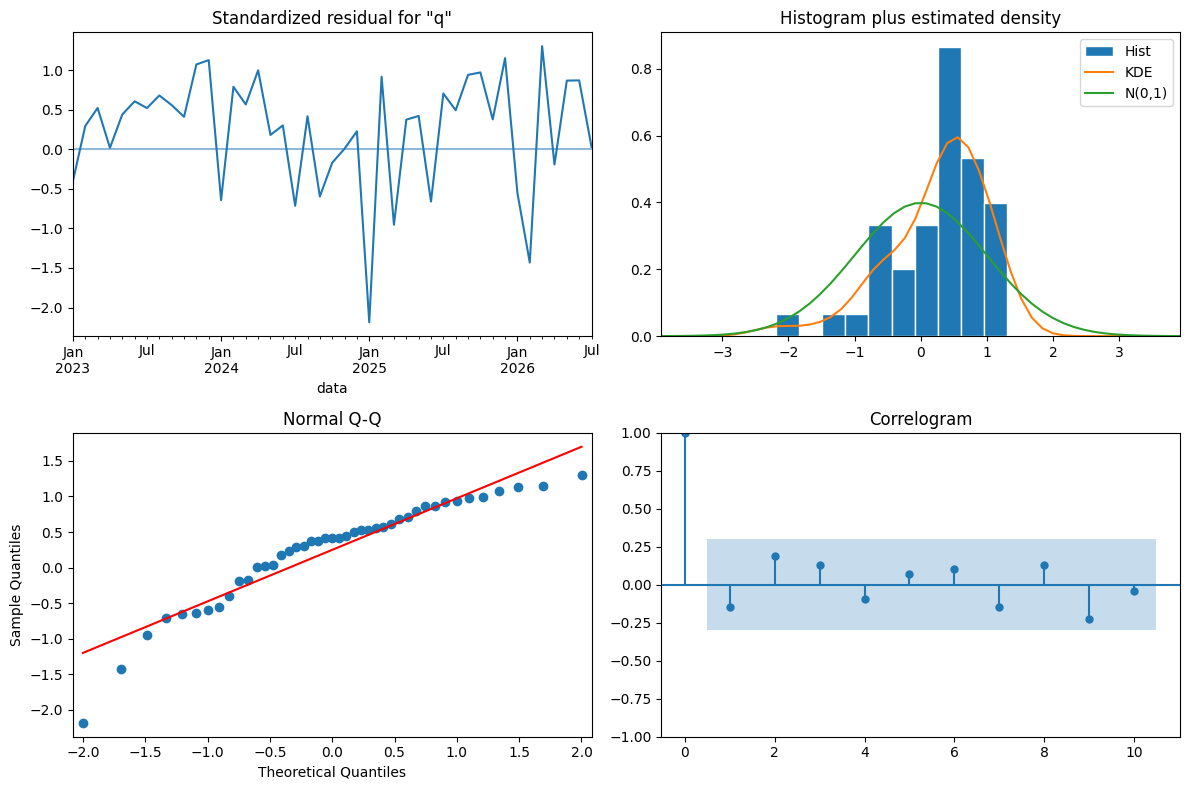

      lb_stat  lb_pvalue
12  17.309347   0.138327
24  27.711387   0.272401


In [18]:
serie_idx = serie_idx.asfreq("MS")

modelo_final = sm.tsa.SARIMAX(
    serie_idx, order=(0,1,0), seasonal_order=(0,1,1,12),
    enforce_stationarity=False, enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)
print(resultado_final.summary())

# Diagnóstico visual dos resíduos: 4 gráficos de uma vez
resultado_final.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig("pix_sarima_diagnostico.png", dpi=150)
plt.show()

# Teste formal de Ljung-Box: os resíduos ainda têm autocorrelação residual?
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resultado_final.resid, lags=[12, 24], return_df=True)
print(lb)

rodei o modelo e veio um resultado estranho no sigma2, erro padrao muito pequeno
(tipo 1e-15) e um p valor bugado. acho que é pq os numeros da serie sao muito grandes
(centena de milhao), deve estar dando problema de arredondamento no calculo.

vou tentar dividir a serie por 1 milhao antes de rodar de novo, só pra deixar os numeros
menores, não muda a serie em si só a escala


In [19]:
# Reescala para milhões, mantendo a mesma forma da série
serie_escalada = serie_idx / 1_000_000  # agora em "milhões de transações/dia"

resultados = []
for order, seasonal_order in candidatos:
    try:
        modelo = sm.tsa.SARIMAX(
            endog=serie_escalada,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)
        resultados.append({
            "order": order, "seasonal_order": seasonal_order,
            "AIC": resultado.aic, "BIC": resultado.bic
        })
        print(f"SARIMA{order}x{seasonal_order} -> AIC={resultado.aic:.2f}, BIC={resultado.bic:.2f}")
    except Exception as e:
        print(f"Falhou {order}x{seasonal_order}: {e}")

melhor = sorted(resultados, key=lambda x: x["AIC"])[0]
print(f"\nMelhor modelo por AIC: SARIMA{melhor['order']}x{melhor['seasonal_order']}")

SARIMA(0, 1, 0)x(0, 1, 0, 12) -> AIC=725.26, BIC=727.27
SARIMA(1, 1, 0)x(0, 1, 0, 12) -> AIC=727.25, BIC=731.27
SARIMA(0, 1, 1)x(0, 1, 0, 12) -> AIC=715.07, BIC=719.05
SARIMA(1, 1, 1)x(0, 1, 0, 12) -> AIC=707.20, BIC=713.17
SARIMA(0, 1, 0)x(1, 1, 0, 12) -> AIC=575.59, BIC=579.16
SARIMA(0, 1, 0)x(0, 1, 1, 12) -> AIC=568.13, BIC=571.65

Melhor modelo por AIC: SARIMA(0, 1, 0)x(0, 1, 1, 12)


                                      SARIMAX Results                                       
Dep. Variable:                          qtd_por_dia   No. Observations:                   69
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -282.065
Date:                              Thu, 20 Aug 2026   AIC                            568.131
Time:                                      20:06:16   BIC                            571.653
Sample:                                  11-01-2020   HQIC                           569.430
                                       - 07-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12       0.4654      0.208      2.241      0.025       0.058       0.873
sigma2      2.883e+

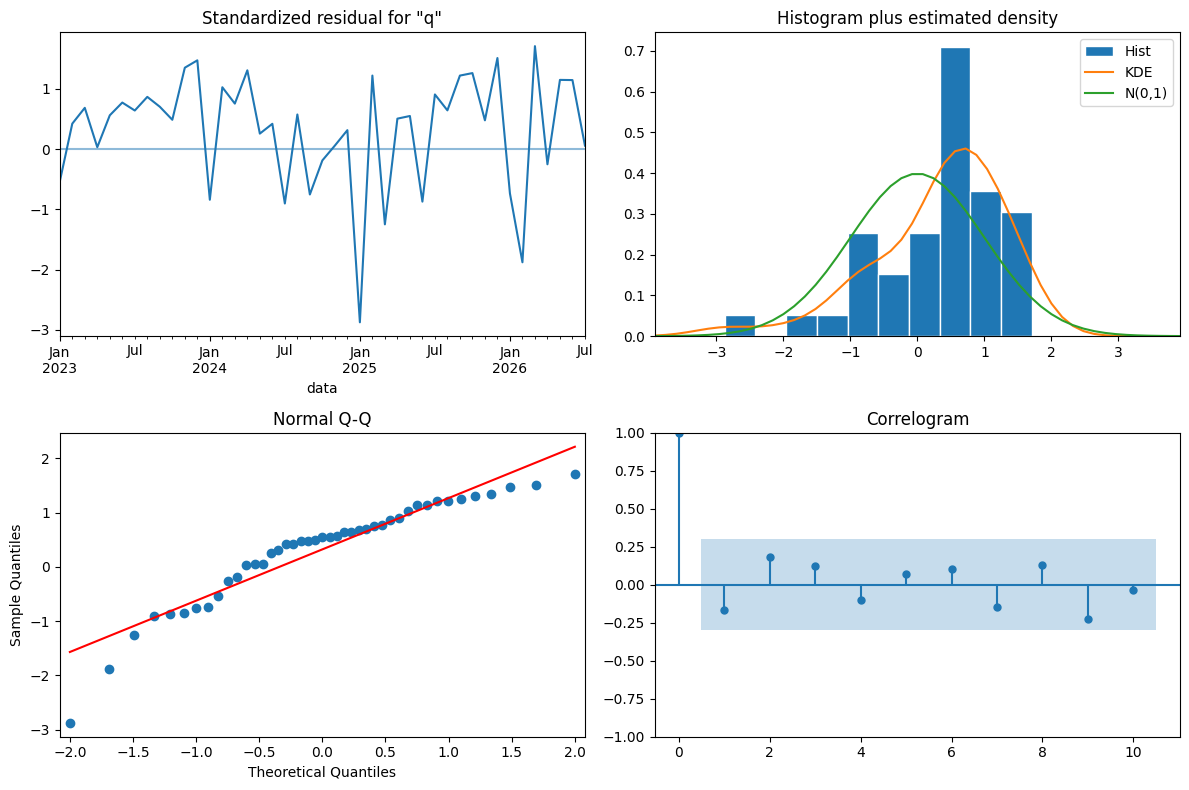

      lb_stat  lb_pvalue
12  16.641642   0.163582
24  26.068906   0.349678


In [20]:
# rodando nosso modelo bom, mas com a serie dividida por 1 milhao pra nao dar erro de novo
modelo_final = sm.tsa.SARIMAX(
    endog=serie_escalada, order=(0,1,0), seasonal_order=(0,1,1,12),
    enforce_stationarity=False, enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)
print(resultado_final.summary())

resultado_final.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig("pix_sarima_diagnostico.png", dpi=150)
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(resultado_final.resid, lags=[12, 24], return_df=True))

depois de dividir por 1 milhao o sigma2 saiu certo (numero normal, p valor ok).
o modelo continua sendo o SARIMA(0,1,0)(0,1,1,12), o mesmo de antes.

só reparei que o coeficiente ma.S.L12 nao deu significativo (p=0.68), então talvez esse
termo nao esteja ajudando muito, mas como foi ele que deu o menor AIC vou manter por
enquanto e colocar isso como limitação no relatorio.

o ljung-box deu p=0.21 e a heterocedasticidade deu p=0.95, então pelo menos os residuos
parecem ok, sem autocorrelação sobrando.

proximo passo: fazer a previsão pra frente com esse modelo e depois coletar os dados dos
concorrentes (boleto, ted, cartao) pra fazer a parte de causalidade


agora falta pegar os concorrentes pra fechar a primeira entrega: boleto/TED (mensal) e
cartao credito/debito (trimestral). o endpoint muda um pouco: o mensal usa o parametro
AnoMes (igual o pix), mas os trimestrais usam um parametro chamado trimestre, no formato
AAAAT (ex: '20261' = 1 trimestre de 2026)


In [21]:
# testando o endpoint mensal (boleto, TED, DOC) num mes só pra ver que colunas vem
import requests
import pandas as pd

def coletar_mensal(ano_mes):
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/"
        f"MeiosdePagamentosMensalDA(AnoMes=@AnoMes)"
        f"?@AnoMes='{ano_mes}'&$format=json"
    )
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return pd.DataFrame(resp.json().get("value", []))

df_teste_mensal = coletar_mensal("202506")
print(df_teste_mensal.shape)
df_teste_mensal.head()


(14, 13)


,AnoMes,quantidadePix,valorPix,quantidadeTED,valorTED,quantidadeTEC,valorTEC,quantidadeCheque,valorCheque,quantidadeBoleto,valorBoleto,quantidadeDOC,valorDOC
0,202607,7975139.94,3800592.19,68602.77,4058803.01,0.0,0.0,6607.51,30011.40,341104.26,577982.13,0.0,0.0
1,202606,7699815.65,3599270.78,64041.78,4235160.17,0.0,0.0,6693.47,30773.59,340587.57,577082.91,0.0,0.0
2,202605,7854699.48,3478034.84,65540.90,3828232.89,0.0,0.0,6299.28,28997.49,321873.66,541107.26,0.0,0.0
3,202604,7370602.06,3421732.27,65272.11,4064285.57,0.0,0.0,6667.11,32464.83,326984.42,552159.56,0.0,0.0
4,202603,7442903.15,3533664.12,69211.12,4196796.01,0.0,0.0,7367.69,32865.28,346881.81,572564.03,0.0,0.0


In [22]:
# mesma logica do pix: idempotente (pula mes que já baixou) e timeout de 120s
import os
import time

def coletar_meios_pagamento_mensal(ano_inicio=2020, mes_inicio=11, ano_fim=2026, mes_fim=7):
    caminho = "meios_pagamento_mensal.csv"
    if os.path.exists(caminho):
        ja_tem = set(pd.read_csv(caminho)["AnoMes"].astype(str))
    else:
        ja_tem = set()

    primeira = not os.path.exists(caminho)
    ano, mes = ano_inicio, mes_inicio
    while (ano, mes) <= (ano_fim, mes_fim):
        ano_mes = f"{ano}{mes:02d}"
        if ano_mes in ja_tem:
            print(f"{ano_mes}: já tem, pulando")
        else:
            try:
                df = coletar_mensal(ano_mes)
                if len(df) > 0:
                    df.to_csv(caminho, mode="a", header=primeira, index=False)
                    primeira = False
                    print(f"{ano_mes}: {len(df)} linhas -> salvo")
                else:
                    print(f"{ano_mes}: veio vazio (provavelmente ainda não publicado)")
            except Exception as e:
                print(f"Falhou em {ano_mes}: {e}")
        mes += 1
        if mes > 12:
            mes, ano = 1, ano + 1
        time.sleep(0.5)

coletar_meios_pagamento_mensal()


202011: 69 linhas -> salvo
202012: 68 linhas -> salvo
202101: 67 linhas -> salvo
202102: 66 linhas -> salvo
202103: 65 linhas -> salvo
202104: 64 linhas -> salvo
202105: 63 linhas -> salvo
202106: 62 linhas -> salvo
202107: 61 linhas -> salvo
202108: 60 linhas -> salvo
202109: 59 linhas -> salvo
202110: 58 linhas -> salvo
202111: 57 linhas -> salvo
202112: 56 linhas -> salvo
202201: 55 linhas -> salvo
202202: 54 linhas -> salvo
202203: 53 linhas -> salvo
202204: 52 linhas -> salvo
202205: 51 linhas -> salvo
202206: 50 linhas -> salvo
202207: 49 linhas -> salvo
202208: 48 linhas -> salvo
202209: 47 linhas -> salvo
202210: 46 linhas -> salvo
202211: 45 linhas -> salvo
202212: 44 linhas -> salvo
202301: 43 linhas -> salvo
202302: 42 linhas -> salvo
202303: 41 linhas -> salvo
202304: 40 linhas -> salvo
202305: 39 linhas -> salvo
202306: 38 linhas -> salvo
202307: 37 linhas -> salvo
202308: 36 linhas -> salvo
202309: 35 linhas -> salvo
202310: 34 linhas -> salvo
202311: 33 linhas -> salvo
2

In [24]:
# funcao pra gerar a lista de trimestres, tipo 20204, 20211, 20212...
def gerar_trimestres(ano_i, trim_i, ano_f, trim_f):
    trims = []
    ano, trim = ano_i, trim_i
    while (ano, trim) <= (ano_f, trim_f):
        trims.append(f"{ano}{trim}")
        trim += 1
        if trim > 4:
            trim, ano = 1, ano + 1
    return trims

def coletar_trimestral(endpoint, trimestre):
    url = (
        f"https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/"
        f"{endpoint}(trimestre=@trimestre)"
        f"?@trimestre='{trimestre}'&$format=json"
    )
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return pd.DataFrame(resp.json().get("value", []))

# testando um trimestre só, pra ver as colunas antes de baixar tudo
try:
    df_teste_trimestral = coletar_trimestral("MeiosdePagamentosTrimestralDA", "20261")
    print(df_teste_trimestral.shape)
    df_teste_trimestral.head()
except Exception as e:
    print(f"deu erro: {e}")


deu erro: 500 Server Error: Internal Server Error for url: https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/MeiosdePagamentosTrimestralDA(trimestre=@trimestre)?@trimestre='20261'&$format=json


In [25]:
# e por ultimo o de cartao (estoque e transacoes), mesmo esquema
def coletar_cartoes():
    caminho = "cartoes_trimestral.csv"
    if os.path.exists(caminho):
        existente = pd.read_csv(caminho)
        ja_tem = set(existente["trimestre"].astype(str)) if "trimestre" in existente.columns else set()
    else:
        ja_tem = set()

    primeira = not os.path.exists(caminho)
    trimestres = gerar_trimestres(2020, 4, 2026, 2)
    for tri in trimestres:
        if tri in ja_tem:
            print(f"{tri}: já tem, pulando")
            continue
        try:
            df = coletar_trimestral("Quantidadeetransacoesdecartoes", tri)
            if len(df) > 0:
                df["trimestre"] = tri
                df.to_csv(caminho, mode="a", header=primeira, index=False)
                primeira = False
                print(f"{tri}: {len(df)} linhas -> salvo")
            else:
                print(f"{tri}: veio vazio")
        except Exception as e:
            print(f"Falhou em {tri}: {e}")
        time.sleep(0.5)

coletar_cartoes()


20204: 2685 linhas -> salvo
20211: 2571 linhas -> salvo
20212: 2458 linhas -> salvo
20213: 2343 linhas -> salvo
20214: 2229 linhas -> salvo
20221: 2112 linhas -> salvo
20222: 1996 linhas -> salvo
20223: 1880 linhas -> salvo
20224: 1761 linhas -> salvo
20231: 1644 linhas -> salvo
20232: 1528 linhas -> salvo
20233: 1408 linhas -> salvo
20234: 1286 linhas -> salvo
20241: 1163 linhas -> salvo
20242: 1035 linhas -> salvo
20243: 906 linhas -> salvo
20244: 777 linhas -> salvo
20251: 649 linhas -> salvo
20252: 522 linhas -> salvo
20253: 393 linhas -> salvo
20254: 261 linhas -> salvo
20261: 130 linhas -> salvo
20262: veio vazio


ok, com isso da pra fechar a primeira entrega: tenho o pix (mensal, já validado e com o
modelo base rodando), boleto/TED (mensal) e cartao credito/debito + estoque (trimestral).
os arquivos que ficaram salvos:

- pix_serie_mensal.csv
- meios_pagamento_mensal.csv
- pix_microdados.csv
- pix_por_finalidade.csv
- cartoes_trimestral.csv


falta só dar uma olhada rapida nas colunas de cada um pra confirmar o nome certo da
coluna de valor/quantidade de cada meio de pagamento antes de partir pra parte de
causalidade (isso fica pra proxima etapa)


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

mensal = pd.read_csv("meios_pagamento_mensal.csv")
mensal["data"] = pd.to_datetime(mensal["AnoMes"], format="%Y%m")
mensal = mensal.sort_values("data")

print(mensal.shape)
print(mensal.dtypes)
print(mensal.isna().sum())
mensal.describe()

(2415, 14)
AnoMes                       int64
quantidadePix              float64
valorPix                   float64
quantidadeTED              float64
valorTED                   float64
quantidadeTEC              float64
valorTEC                   float64
quantidadeCheque           float64
valorCheque                float64
quantidadeBoleto           float64
valorBoleto                float64
quantidadeDOC              float64
valorDOC                   float64
data                datetime64[ns]
dtype: object
AnoMes              0
quantidadePix       0
valorPix            0
quantidadeTED       0
valorTED            0
quantidadeTEC       0
valorTEC            0
quantidadeCheque    0
valorCheque         0
quantidadeBoleto    0
valorBoleto         0
quantidadeDOC       0
valorDOC            0
data                0
dtype: int64


,AnoMes,quantidadePix,valorPix,quantidadeTED,valorTED,quantidadeTEC,valorTEC,quantidadeCheque,valorCheque,quantidadeBoleto,valorBoleto,quantidadeDOC,valorDOC,data
count,2415.000000,2.415000e+03,2.415000e+03,2415.000000,2.415000e+03,2415.000000,2415.000000,2415.000000,2415.000000,2415.000000,2415.000000,2415.000000,2415.000000,2415
mean,202422.981781,5.297386e+06,2.331563e+06,71202.778621,3.655782e+06,222.253043,497.396385,10300.275188,38970.355818,342756.075582,513128.680836,1333.983333,1210.585449,2024-08-10 21:20:47.701863168
min,202011.000000,3.286736e+04,2.919699e+04,58891.000000,2.381021e+06,0.000000,0.000000,6264.060000,26618.210000,306432.320000,338584.620000,0.000000,0.000000,2020-11-01 00:00:00
25%,202309.000000,3.830814e+06,1.527905e+06,64506.600000,3.378765e+06,0.000000,0.000000,7934.510000,33738.320000,332501.150000,479459.520000,0.000000,0.000000,2023-09-01 00:00:00
50%,202411.000000,5.673012e+06,2.456994e+06,68602.770000,3.683199e+06,0.000000,0.000000,9616.440000,36429.910000,342147.160000,516117.790000,0.000000,0.000000,2024-11-01 00:00:00
75%,202510.000000,6.965545e+06,3.122098e+06,75539.520000,3.857370e+06,602.370000,1316.400000,12188.200000,43399.520000,353610.130000,549409.885000,2378.170000,2279.990000,2025-10-01 00:00:00
max,202607.000000,7.975140e+06,3.800592e+06,191703.380000,4.632905e+06,1305.510000,2757.910000,22020.430000,58871.560000,380679.530000,603920.360000,22362.970000,13980.280000,2026-07-01 00:00:00
std,140.164540,2.027749e+06,9.503889e+05,10863.056331,3.703844e+05,340.379423,757.172848,3284.027144,7689.443590,15391.586511,47130.671168,2422.419189,2097.948082,NaN


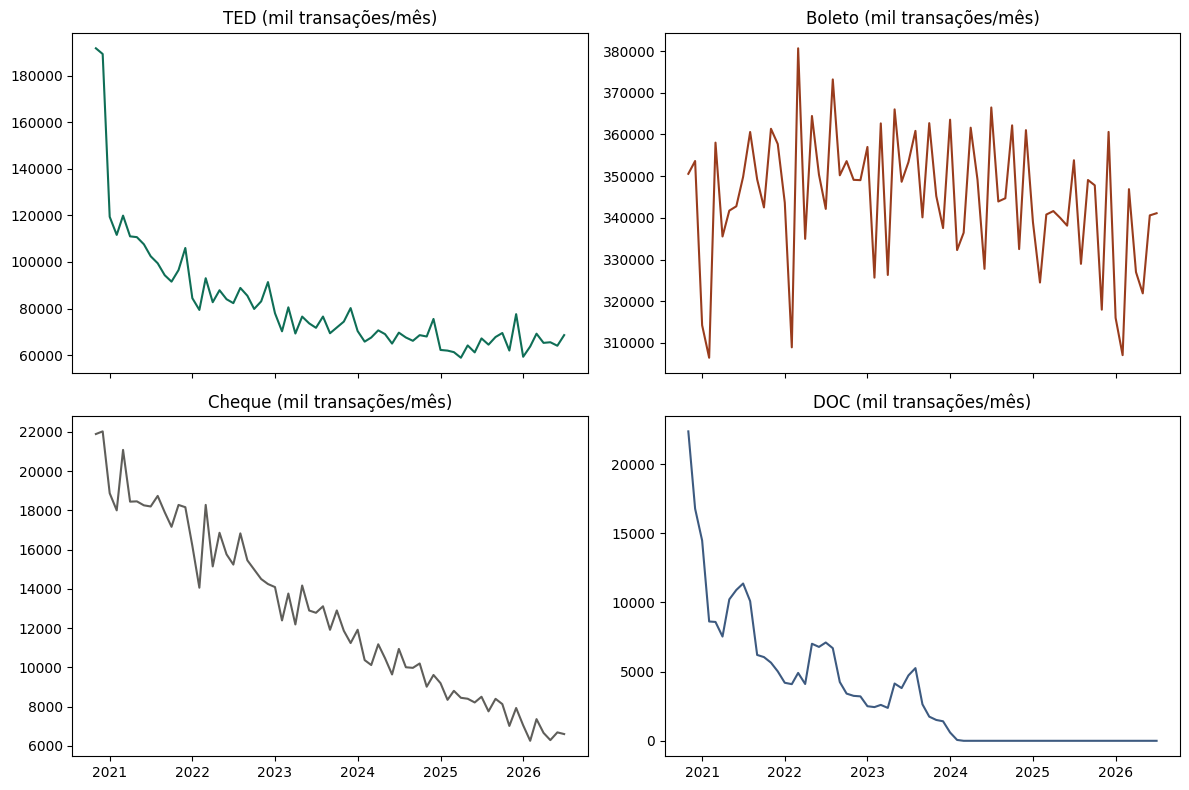

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0, 0].plot(mensal["data"], mensal["quantidadeTED"], color="#0F6E56")
axs[0, 0].set_title("TED (mil transações/mês)")

axs[0, 1].plot(mensal["data"], mensal["quantidadeBoleto"], color="#993C1D")
axs[0, 1].set_title("Boleto (mil transações/mês)")

axs[1, 0].plot(mensal["data"], mensal["quantidadeCheque"], color="#5F5E5A")
axs[1, 0].set_title("Cheque (mil transações/mês)")

axs[1, 1].plot(mensal["data"], mensal["quantidadeDOC"], color="#3D5A80")
axs[1, 1].set_title("DOC (mil transações/mês)")

plt.tight_layout()
plt.savefig("concorrentes_mensal_exploratoria.png", dpi=150)
plt.show()

# só olhando essa figura já dá pra ver a hipótese do trabalho: cheque e DOC praticamente
# sumiram, boleto meio estável, TED com uma leve queda - bate com a ideia de substituição
# em graus diferentes por instrumento, que é a pergunta do projeto

In [28]:
cartoes = pd.read_csv("cartoes_trimestral.csv")

print(cartoes.shape)
print(cartoes.dtypes)
print(cartoes.isna().sum())
print(cartoes["nomeFuncao"].unique())
cartoes.describe()

(31737, 11)
trimestre                          int64
nomeBandeira                      object
nomeFuncao                        object
produto                           object
modalidade                        object
qtdCartoesEmitidos                 int64
qtdCartoesAtivos                   int64
qtdTransacoesNacionais             int64
valorTransacoesNacionais         float64
qtdTransacoesInternacionais        int64
valorTransacoesInternacionais    float64
dtype: object
trimestre                        0
nomeBandeira                     0
nomeFuncao                       0
produto                          0
modalidade                       0
qtdCartoesEmitidos               0
qtdCartoesAtivos                 0
qtdTransacoesNacionais           0
valorTransacoesNacionais         0
qtdTransacoesInternacionais      0
valorTransacoesInternacionais    0
dtype: int64
['Débito' 'Crédito' 'Pré-Pago']


,trimestre,qtdCartoesEmitidos,qtdCartoesAtivos,qtdTransacoesNacionais,valorTransacoesNacionais,qtdTransacoesInternacionais,valorTransacoesInternacionais
count,31737.000000,3.173700e+04,3.173700e+04,3.173700e+04,3.173700e+04,3.173700e+04,3.173700e+04
mean,20223.990705,1.034426e+07,3.651443e+06,8.686968e+07,7.754911e+09,2.929968e+05,1.091485e+08
std,13.464824,2.731679e+07,8.515193e+06,2.195972e+08,1.755897e+10,1.075738e+06,4.570167e+08
min,20204.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,20213.000000,1.793800e+05,4.553200e+04,6.192120e+05,9.786964e+07,0.000000e+00,0.000000e+00
50%,20222.000000,1.095905e+06,3.888910e+05,8.266714e+06,1.050044e+09,2.724000e+03,7.322332e+05
75%,20233.000000,7.501658e+06,2.745515e+06,4.557774e+07,5.072279e+09,8.714700e+04,2.838885e+07
max,20261.000000,2.252743e+08,8.105000e+07,1.437844e+09,1.195906e+11,1.199593e+07,5.805875e+09


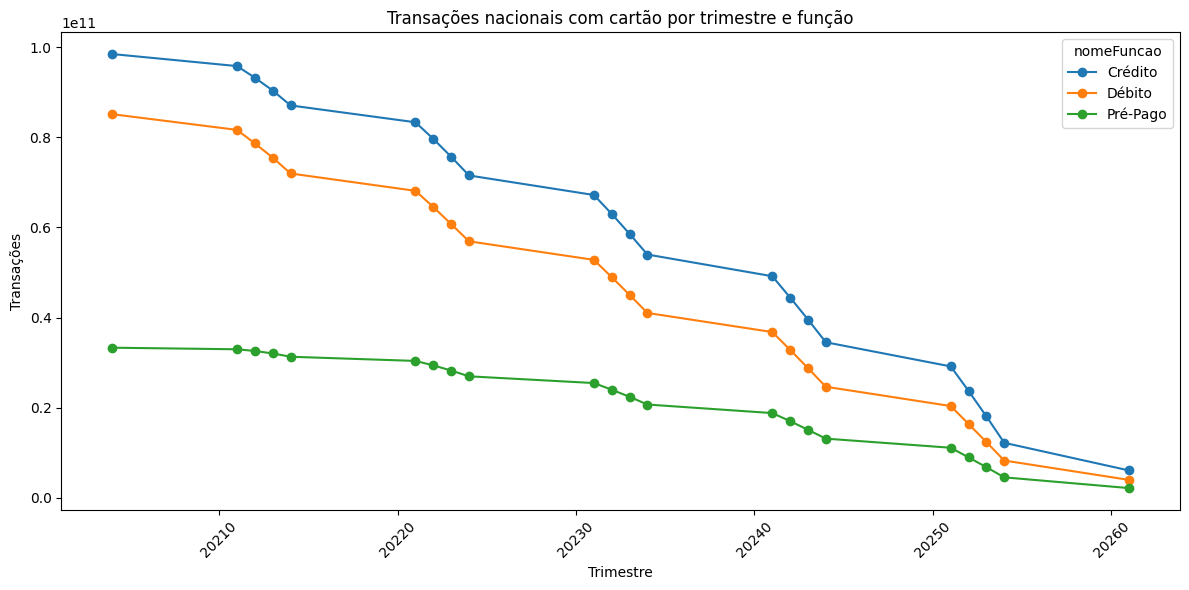

In [29]:
por_trimestre_funcao = (
    cartoes.groupby(["trimestre", "nomeFuncao"])["qtdTransacoesNacionais"]
    .sum()
    .unstack()
    .sort_index()
)

por_trimestre_funcao.plot(figsize=(12, 6), marker="o")
plt.title("Transações nacionais com cartão por trimestre e função")
plt.ylabel("Transações")
plt.xlabel("Trimestre")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("concorrentes_cartoes_exploratoria.png", dpi=150)
plt.show()